# Explore Usage Data

TODO: Data Science students — explore mock usage patterns in `datasets/agent_usage.csv`.

Questions to investigate:
- Which agents have the highest run counts?
- What is the error rate distribution?
- How do downloads correlate with runs?

Agents with the highest run counts
                  agent_name  total_runs  recent_runs
7        Meeting Notes Agent        9800          520
3      Resume Reviewer Agent        8900          450
8    Content Generator Agent        7200          310
4          Study Buddy Agent        6500          280
0     Email Summarizer Agent        5420          320
6         Data Cleaner Agent        4100          150
9      Budget Analyzer Agent        3800          120
1  GitHub Issue Triage Agent        3100          180
2     Calendar Planner Agent        2800           95
5   Travel Deal Finder Agent        2200           75


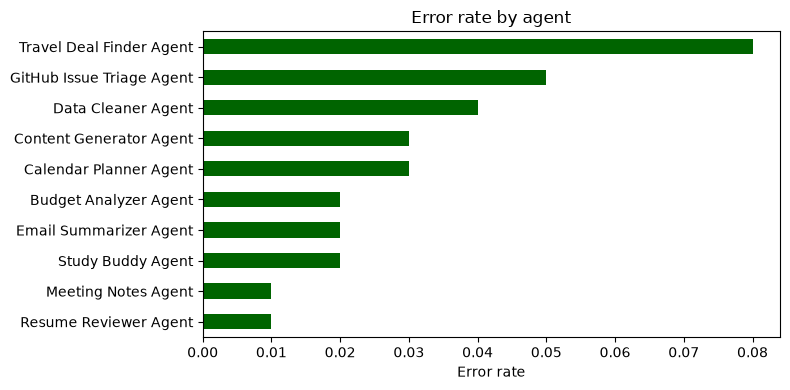

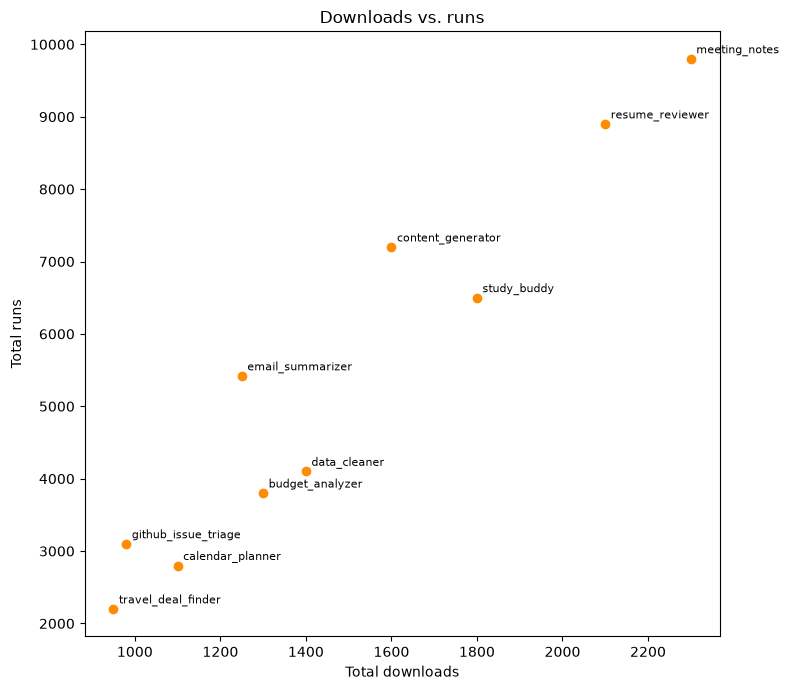

In [20]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

DATASETS_DIR = Path('../../datasets')
usage = pd.read_csv(DATASETS_DIR / 'agent_usage.csv')
#usage.head()


#Which agents have the highest run counts?
top_by_total_runs = usage.sort_values('total_runs', ascending=False)[['agent_name', 'total_runs', 'recent_runs']]
print("Agents with the highest run counts")
print(top_by_total_runs)


#What is the error rate distribution?
usage['error_rate'].describe()
fig, ax = plt.subplots(figsize=(8, 4))
usage.sort_values('error_rate').plot(kind='barh', x='agent_name', y='error_rate', ax=ax, legend=False, color='#006400')
ax.set_xlabel('Error rate')
ax.set_ylabel('')
ax.set_title('Error rate by agent')
plt.tight_layout()
plt.show()


# How do downloads correlate with runs
fig, ax = plt.subplots(figsize=(8, 7))
ax.scatter(usage['total_downloads'], usage['total_runs'], color='#FF8C00')
for _, row in usage.iterrows():
    ax.annotate(row['agent_id'], (row['total_downloads'], row['total_runs']),
                fontsize=8, xytext=(4, 4), textcoords='offset points')
ax.set_xlabel('Total downloads')
ax.set_ylabel('Total runs')
ax.set_title('Downloads vs. runs')
plt.tight_layout()
plt.show()
